# Scribble Evaluation — Age Interpolation (40–80)
Load the scribbles, generate conditioned photos,
compute MMD vs age-based target distribution (40–80 yo men),
fit PCA on age-40 vs age-80 embeddings, project everything, and pick 14 photos evenly along the age axis.

## 1. Setup

In [1]:
import os, sys, json, gc, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torchvision.transforms.functional as TF
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from IPython.display import display
from huggingface_hub import login
from google.colab import userdata
import wandb


if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass('Enter your GitHub personal access token: ')

    repo_url  = f'https://{token}@github.com/orineo1/conditional-matching-paper.git'
    repo_name = 'conditional-matching-paper'
    branch    = 'main'

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f'/content/{repo_name}'
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

repo_path = f'/content/{repo_name}/SD_cond_SD_controlnet'  # ← fixed
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)


import random

GLOBAL_SEED=1

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'[Seed] All random seeds set to {seed}')

set_global_seed(GLOBAL_SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.3 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 7154, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 7154 (delta 132), reused 78 (delta 69), pack-reused 6986 (from 2)
Receiving objects: 100% (7154/7154), 1.40 GiB | 20.00 MiB/s, done.
Resolving deltas: 100% (2397/2397), done.
Updating files: 100% (109/109), done.
Already on 'main'
Your branch is up to date with 'origin/main'.
[Seed] All random seeds set to 1
Device: cuda


## 2. Config

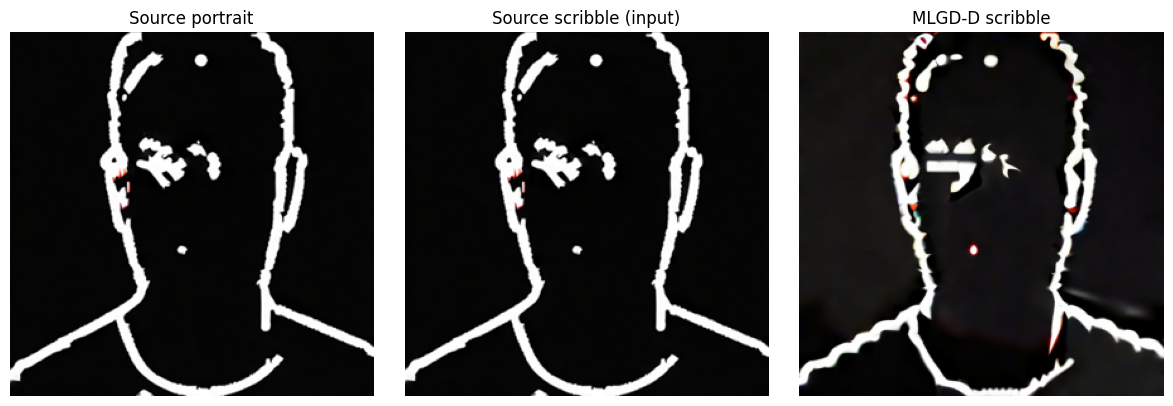

Loaded scribble from /content/conditional-matching-paper/SD_cond_SD_controlnet/experiments/AgeInterpolation


In [2]:
## 5. Load Best Run Scribble

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    run_dir = Path('/content/conditional-matching-paper/SD_cond_SD_controlnet/experiments/AgeInterpolation')
else:
    run_dir = Path('/mnt/c/Users/orine/PycharmProjects/conditional-matching-paper/SD_cond_SD_controlnet/experiments/AgeInterpolation')

scribble_pil_1  = Image.open(run_dir / 'scribble_mlgdd.png')
source_scribble = Image.open(run_dir / 'scribble_source.png')
source_img      = Image.open(run_dir / 'source_portrait.png')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [source_img, source_scribble, scribble_pil_1],
    ['Source portrait', 'Source scribble (input)', 'MLGD-D scribble'],
):
    ax.imshow(img); ax.axis('off'); ax.set_title(title)
plt.tight_layout(); display(fig); plt.close()

scribble_pil = scribble_pil_1
print(f'Loaded scribble from {run_dir}')

In [3]:
# ── Age range ─────────────────────────────────────────────────────────────────
AGE_MIN          = 40     # inclusive
AGE_MAX          = 80     # exclusive  (so 40, 41, ..., 79)
AGE_STEP         = 1
AGES             = list(range(AGE_MIN, AGE_MAX, AGE_STEP))

# PCA anchor ages — used to FIT the age axis
PCA_YOUNG_AGE    = 40     # youngest anchor
PCA_OLD_AGE      = 79     # oldest anchor
N_PCA_ANCHOR     = 10     # how many images to use per anchor when fitting PCA

# Number of picks to display along the age axis
NUM_PICKS        = 14

# Generation params
CONTROLNET_SCALE = 0.5
N_EVAL           = 100
N_TARGETS_PER_AGE = 3     # images per age used to build target CLIP embeddings
EVAL_PROMPT      = 'a superrealistic professional photograph of'

print(f'Age range: {AGE_MIN}–{AGE_MAX-1}  ({len(AGES)} ages)')
print(f'PCA anchors: age {PCA_YOUNG_AGE} vs age {PCA_OLD_AGE}  ({N_PCA_ANCHOR} each)')
print(f'Picks along age axis: {NUM_PICKS}')

Age range: 40–79  (40 ages)
PCA anchors: age 40 vs age 79  (10 each)
Picks along age axis: 14


## 3. Load Models

In [4]:
from models     import load_models
from clip_utils import load_clip_model

architect, sprinter        = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print('Models loaded.')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


## 4. Helpers

In [5]:
from generation    import generate_and_store_cs
from clip_utils    import encode_images_clip
from visualization import plot_row
from metrics       import compute_mmd

def pil_to_tensor(pil_list):
    return torch.cat(
        [TF.to_tensor(img).unsqueeze(0) for img in pil_list], dim=0
    ).to(next(clip_model.parameters()).device)


def generate_eval_photos(scribble_pil, n=N_EVAL, seed=None):
    sprinter.vae.to(dtype=torch.float16)
    generator = None
    if seed is not None:
        generator = torch.Generator(device=sprinter.device).manual_seed(seed)
    photos = []
    with torch.no_grad():
        for start in range(0, n, 2):
            bs = min(2, n - start)
            result = sprinter(
                prompt=[EVAL_PROMPT] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type='pil',
                generator=generator,
            )
            photos.extend(result.images)
    sprinter.vae.to(dtype=torch.float32)
    return photos


def encode_age_prompt(age):
    """Return the text prompt used during target generation for a given age."""
    return (
        f'a superrealistic portrait photograph of a {age}-year-old man, '
        'studio lighting, sharp focus, photographic'
    )


print('Helpers ready.')

Helpers ready.


## 6. Build Age Target Distribution & Encode to CLIP

In [6]:

def generate_and_store_cs(pipe, prompt, cond_pil, num_samples, batch_size=2, cn_scale=0.5, seed=None):
    original_vae_dtype = pipe.vae.dtype
    pipe.vae.to(dtype=torch.float16)
    all_images, all_lats = [], []

    def latents_callback(p, step_index, timestep, cb_kwargs):
        if step_index == p.num_timesteps - 1:
            p._current_latents = cb_kwargs['latents'].detach().cpu().numpy()
        return cb_kwargs

    generator = None
    if seed is not None:
        generator = torch.Generator(device=pipe.device).manual_seed(seed)
    for i in range(0, num_samples, batch_size):
        curr = min(batch_size, num_samples - i)
        result = pipe(
            prompt=[prompt] * curr,
            image=[cond_pil] * curr,
            num_inference_steps=2,
            guidance_scale=0.0,
            controlnet_conditioning_scale=cn_scale,
            callback_on_step_end=latents_callback,
            generator=generator,
        )
        all_images.extend(result.images)
        all_lats.append(pipe._current_latents.reshape(curr, -1))
        print(f'  Progress: {len(all_images)}/{num_samples}', end='\r')
    print()
    pipe.vae.to(dtype=original_vae_dtype)
    return all_images, np.vstack(all_lats)


In [7]:
from sklearn.decomposition import PCA

print(f'Building age target embeddings ({len(AGES)} ages × {N_TARGETS_PER_AGE} = {len(AGES)*N_TARGETS_PER_AGE} images)...')

age_clip_embs = {}   # age -> Tensor [N_TARGETS_PER_AGE, 768]

clip_model.to(device)
with torch.no_grad():
    for age in AGES:
        prompt = encode_age_prompt(age)
        imgs, _ = generate_and_store_cs(
            sprinter, prompt, scribble_pil,
            N_TARGETS_PER_AGE, batch_size=2, cn_scale=CONTROLNET_SCALE,
            seed=GLOBAL_SEED + age * 7,
        )
        embs = encode_images_clip(pil_to_tensor(imgs), clip_model, clip_processor)
        age_clip_embs[age] = embs.cpu()
        # print(f'  age {age:3d}: done', flush=True)
clip_model.to('cpu')

# Flat target tensor for MMD  [N_ages × N_per_age, 768]
all_clip_embeddings = torch.cat([age_clip_embs[a] for a in AGES], dim=0).to(device)
age_labels_arr      = np.array([a for a in AGES for _ in range(N_TARGETS_PER_AGE)])

print(f'\nTarget CLIP embeddings: {all_clip_embeddings.shape}')
norms = all_clip_embeddings.norm(dim=-1)
print(f'Norms min/max: {norms.min():.4f} / {norms.max():.4f}')

Building age target embeddings (40 ages × 3 = 120 images)...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3
  Progress: 3/3

Target CLIP embeddings: torch.Size([120, 768])
Norms min/max: 1.0000 / 1.0000


## 7. Fit PCA on Age-40 vs Age-79 (anchors), Project All Ages

Age axis: mean image embedding of age-40 → age-79


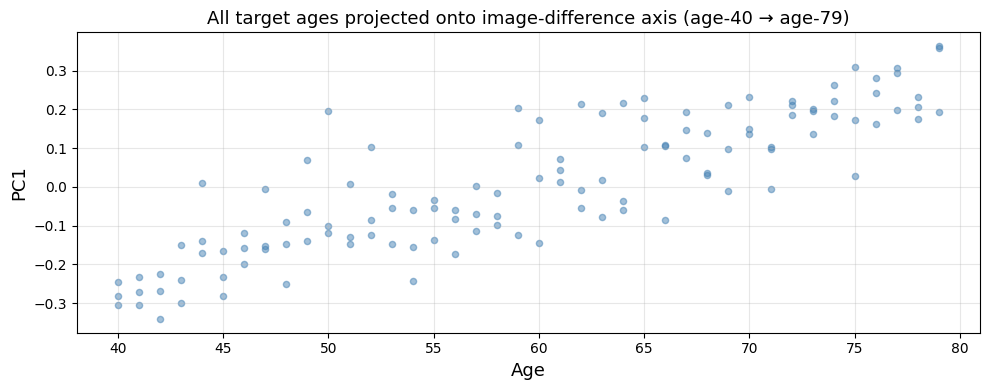

Target scores:  min=-0.341  max=0.364


In [8]:
## 7. Fit Age Axis via Image Embedding Difference (all groups projected)

# ── Mean image embeddings of the two extreme anchor ages ─────────────────────
young_embs_np = age_clip_embs[PCA_YOUNG_AGE].numpy()   # [N_per_age, 768]
old_embs_np   = age_clip_embs[PCA_OLD_AGE].numpy()     # [N_per_age, 768]

young_mean = young_embs_np.mean(axis=0)   # [768]
old_mean   = old_embs_np.mean(axis=0)     # [768]

# ── Age axis = unit vector from young mean → old mean in CLIP image space ────
age_axis = old_mean - young_mean
age_axis = age_axis / np.linalg.norm(age_axis)

print(f'Age axis: mean image embedding of age-{PCA_YOUNG_AGE} → age-{PCA_OLD_AGE}')

# ── Project ALL age groups onto this axis ─────────────────────────────────────
all_target_np = all_clip_embeddings.cpu().numpy()   # [N_ages * N_per_age, 768]
target_scores = all_target_np @ age_axis            # [N_ages * N_per_age]

# ── Sanity plot: all ages vs their projection score ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for age in AGES:
    mask   = age_labels_arr == age
    scores = target_scores[mask]
    ax.scatter([age] * mask.sum(), scores, alpha=0.5, s=20, color='steelblue')

ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('PC1', fontsize=13)
ax.set_title(f'All target ages projected onto image-difference axis '
             f'(age-{PCA_YOUNG_AGE} → age-{PCA_OLD_AGE})', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

print(f'Target scores:  min={target_scores.min():.3f}  max={target_scores.max():.3f}')

## 8. Generate Eval Photos from MLGD-D Scribble

In [9]:
eval_photos = generate_eval_photos(scribble_pil_1, n=N_EVAL, seed=GLOBAL_SEED)

## 9. Compute MMD vs Target

In [10]:
clip_model.to(device)
with torch.no_grad():
    eval_embs = encode_images_clip(
        pil_to_tensor(eval_photos), clip_model, clip_processor
    )
clip_model.to('cpu')

with torch.no_grad():
    mmd_val = compute_mmd(eval_embs, all_clip_embeddings).item()

print(f'MMD (eval photos vs age-{AGE_MIN}–{AGE_MAX-1} target): {mmd_val:.6f}')

MMD (eval photos vs age-40–79 target): 0.359827


## 11. Pick 14 Photos Evenly Along the Age Axis

Eval age-axis scores:  min=-0.207  max=0.302


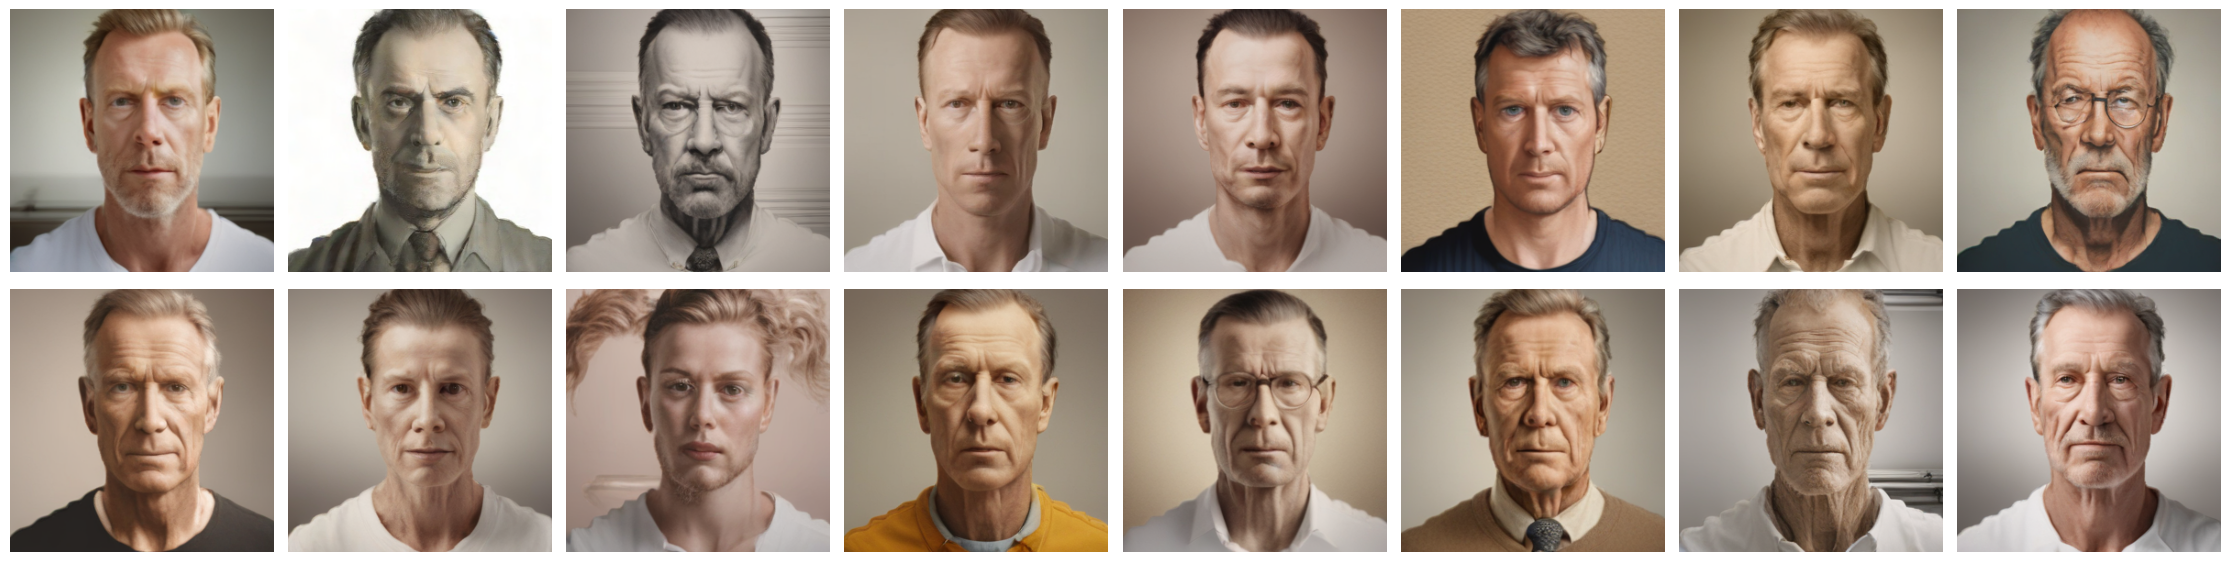

In [11]:
## 10. Project Eval Photos onto Age Axis & Score
eval_np    = eval_embs.cpu().numpy()          # [N_EVAL, 768]
age_scores = eval_np @ age_axis               # [N_EVAL]  — same axis as targets
sorted_idx = np.argsort(age_scores)           # youngest-looking → oldest-looking

print(f'Eval age-axis scores:  min={age_scores.min():.3f}  max={age_scores.max():.3f}')

n_eval = len(eval_photos)
NUM_PICKS=16
# Evenly spaced indices in sorted order
picks = [
    sorted_idx[int(i * (n_eval - 1) / (NUM_PICKS - 1))]
    for i in range(NUM_PICKS)
]

fig, axes = plt.subplots(2, NUM_PICKS // 2, figsize=(NUM_PICKS * 1.4, 6))
for ax, idx in zip(axes.flatten(), picks):
    score = age_scores[idx]
    ax.imshow(eval_photos[idx])
    # ax.set_title(f'{score:.2f}', fontsize=8)
    ax.axis('off')

axes[0, 0].set_xlabel(f'← Young ({AGE_MIN})', fontsize=10, color='royalblue')
axes[0, -1].set_xlabel(f'Old ({AGE_MAX-1}) →', fontsize=10, color='firebrick')
# fig.suptitle(
#     f'Age axis — {NUM_PICKS} photos from youngest to oldest  (MMD={mmd_val:.4f})',
#     fontsize=12,
# )
plt.tight_layout(); display(fig); plt.close()

## 12. Full PCA Scatter: Target Ages + Eval Photos

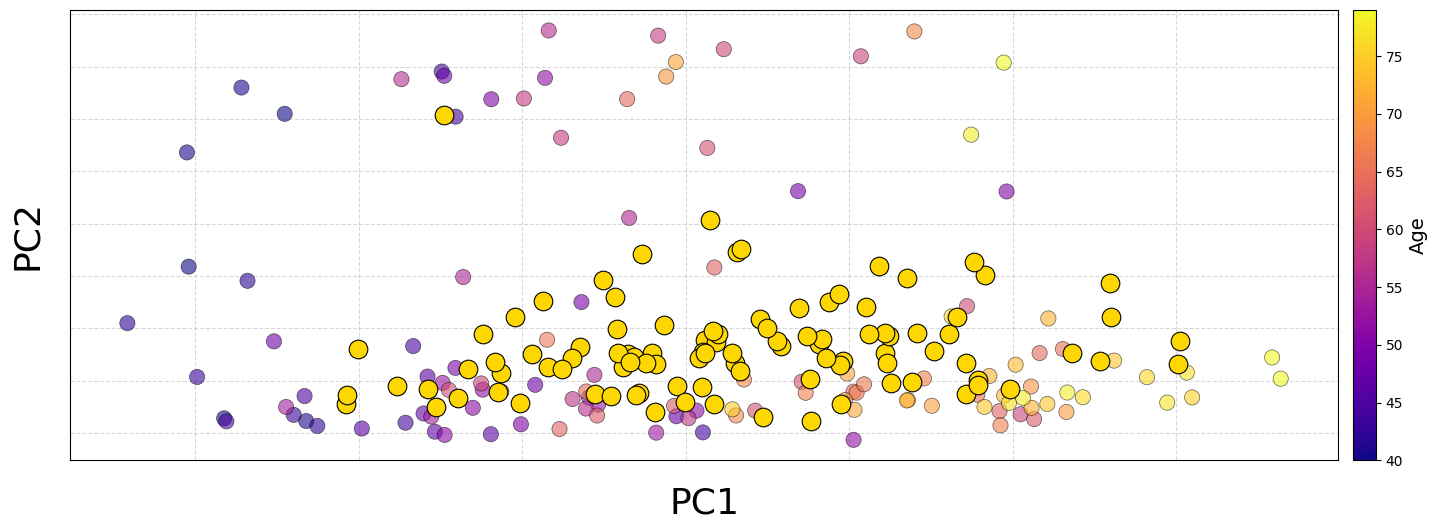

In [12]:
## 11. Plot — Age Axis (same format as gender plot)

from sklearn.decomposition import PCA

# ── Get a 2nd dimension: PCA on residuals after removing the age axis ─────────
all_target_np = all_clip_embeddings.cpu().numpy()
eval_np       = eval_embs.cpu().numpy()

def project_out(embs, axis):
    proj = (embs @ axis)[:, None] * axis[None, :]
    return embs - proj

residuals_target = project_out(all_target_np, age_axis)
residuals_eval   = project_out(eval_np, age_axis)

pca2 = PCA(n_components=1)
pca2.fit(residuals_target)

def to_2d(embs, res):
    x = embs @ age_axis
    y = pca2.transform(res)[:, 0]
    return np.stack([x, y], axis=1)

target_2d = to_2d(all_target_np, residuals_target)
eval_2d   = to_2d(eval_np, residuals_eval)

cmap    = cm.plasma
bg_size = 120

fig, ax = plt.subplots(figsize=(16, 5.4))

# Target distribution — colored by actual age label
ax.scatter(target_2d[:, 0], target_2d[:, 1],
           c=age_labels_arr, cmap=cmap, vmin=AGE_MIN, vmax=AGE_MAX-1,
           s=bg_size, marker='o', alpha=0.6,
           edgecolors='black', linewidths=0.5)

# Eval photos — gold, unchanged
ax.scatter(eval_2d[:, 0], eval_2d[:, 1],
           c='gold', s=int(bg_size * 1.5), marker='o', alpha=1.0,
           edgecolors='black', linewidths=0.8, zorder=10)

# Colorbar in actual age units
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=AGE_MIN, vmax=AGE_MAX-1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('Age', fontsize=14)

ax.set_xlabel('PC1', fontsize=26, labelpad=15)
ax.set_ylabel('PC2', fontsize=26, labelpad=15)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='both', which='both', length=0)
ax.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
display(fig)
plt.close()